<a href="https://colab.research.google.com/github/abdulmueezotoo/dataScience/blob/K-Means/K_Nearest_Neighbor_Classification_on_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Flower Classification Using K-Nearest Neighbor (KNN)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
# Upload data from computer
from google.colab import files
uploaded = files.upload()


Saving Iris.xlsx to Iris (4).xlsx


In [3]:
# Load Excel data
df = pd.read_excel("Iris.xlsx")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
le = LabelEncoder()  # Initialize label encoder
df['Species'] = le.fit_transform(df['Species'])

In [5]:
X = df.drop(['Species', 'Id'], axis=1)  # Features (inputs), dropping 'Id' column
y = df['Species']               # Target (output label)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)  # Using 5 nearest neighbors

In [7]:
cv_scores = cross_val_score(knn, X_train, y_train, cv=5)

In [8]:
print("Cross-validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-validation Accuracy Scores: [0.95833333 0.95833333 0.83333333 1.         0.95833333]
Mean Accuracy: 0.9416666666666667


In [9]:
knn.fit(X_train, y_train)  # Train the KNN model on 80% of the data
y_pred = knn.predict(X_test)  # Predict on the remaining 20%

In [10]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))  # How well did the model perform?
print(classification_report(y_test, y_pred))  # Detailed performance per class

Test Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



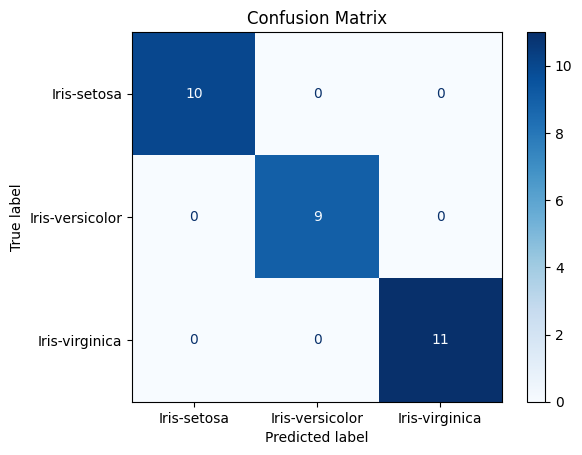

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

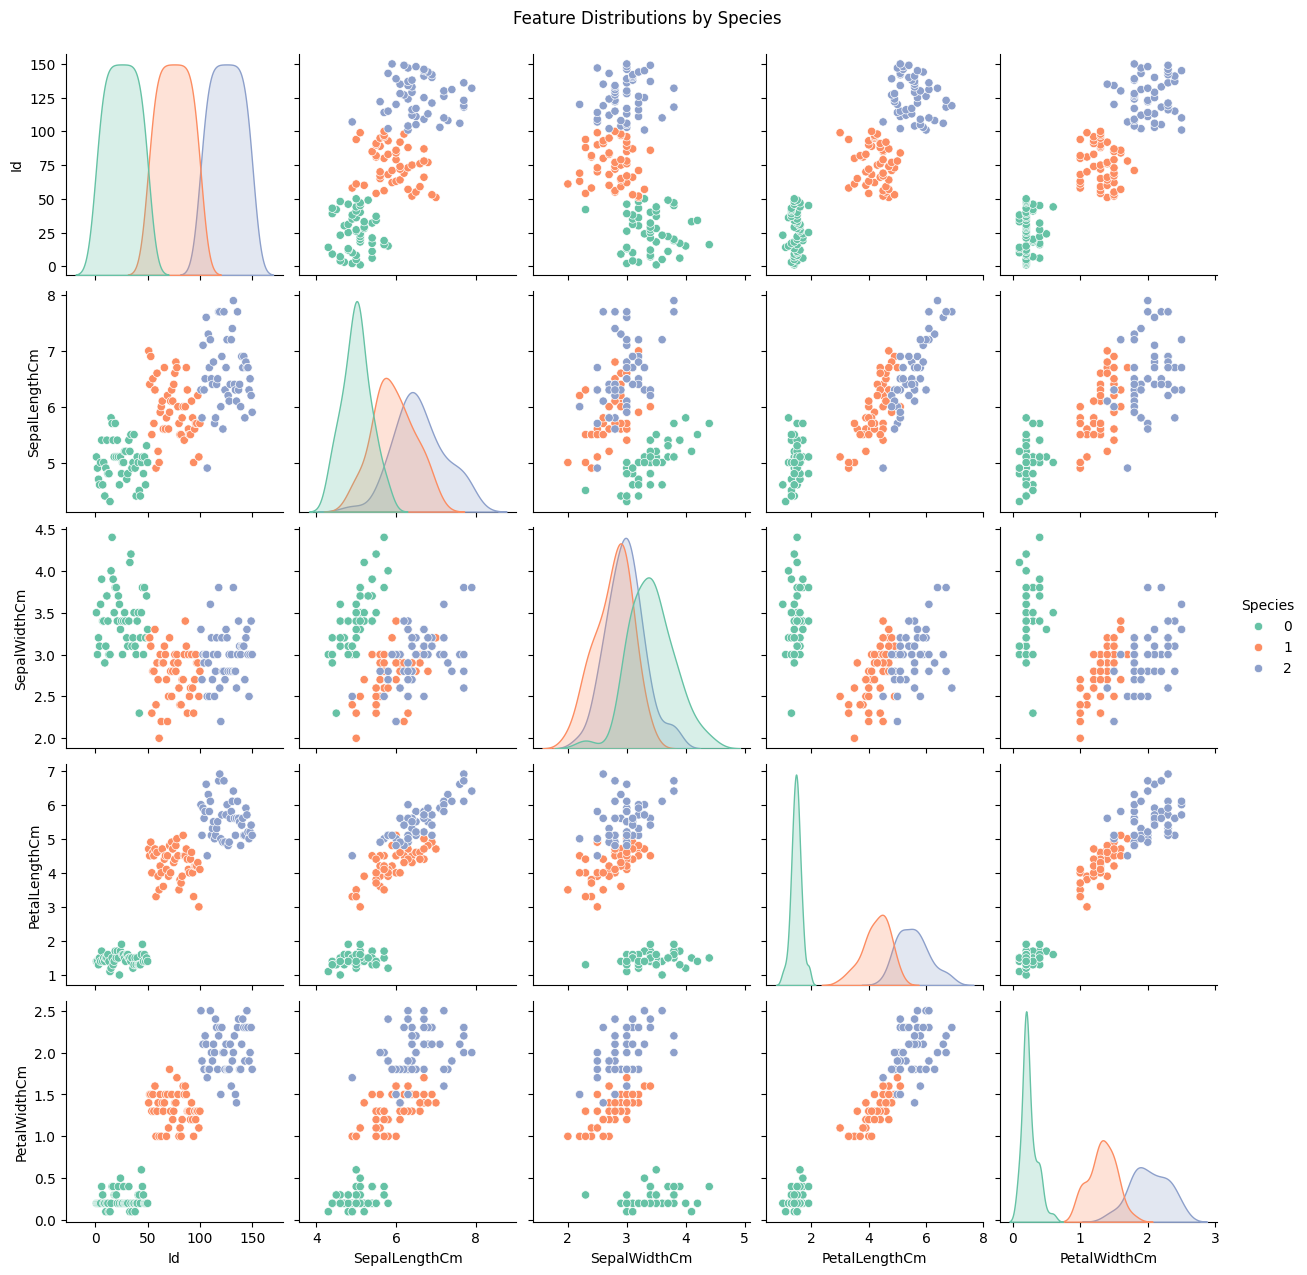

In [12]:
sns.pairplot(df, hue='Species', palette='Set2')
plt.suptitle('Feature Distributions by Species', y=1.02)
plt.show()

In [13]:
# Create a DataFrame for new input with column names matching X_train
new_data_df = pd.DataFrame([[5.5, 2.5, 4.0, 1.3]], columns=X.columns)

# Make prediction
prediction = knn.predict(new_data_df)

# Decode label back to original class name
print("Predicted class:", le.inverse_transform(prediction))

Predicted class: ['Iris-versicolor']
